# Diabetes Prediction: Modelling

Starting from `cleaned_1.csv`, this notebook covers:
1. Load and split (80% train, 20% test held out until the end)
2. Preprocessing pipeline
3. Model comparison with 5-fold cross-validation and class imbalance strategies
4. Hyperparameter tuning (added later)
5. Decision threshold (added later)
6. Final evaluation on the test set (added later)
7. Feature importance and saving the model (added later)

In [1]:
# Import libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load and Split

In [2]:
# Load the cleaned dataset
DATA_PATH = '../../data/cleaned_1.csv'
TARGET = 'diabetes'

df = pd.read_csv(DATA_PATH)

# Stop early if the file is not what we expect
EXPECTED_COLUMNS = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
                    'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
assert list(df.columns) == EXPECTED_COLUMNS, f'Unexpected columns: {list(df.columns)}'
assert df.isna().sum().sum() == 0, 'Missing values found'
assert df.duplicated().sum() == 0, 'Duplicate rows found'

print(f'Shape       : {df.shape}')
print(f'Target rate : {df[TARGET].mean():.3f}')
df.dtypes

Shape       : (95914, 9)
Target rate : 0.088


gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [3]:
# Separate features and target
X = df.drop(columns=TARGET)
y = df[TARGET]

# 80% train, 20% test. stratify keeps the diabetic ratio the same in both sets.
# The test set is NOT used again until the final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Diabetic rate  train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')

Train: (76731, 8)  Test: (19183, 8)
Diabetic rate  train: 0.088  test: 0.088


## 2. Preprocessing Pipeline

In [4]:
# Column groups (from the cleaned dataset)
NUM_COLS = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
BIN_COLS = ['hypertension', 'heart_disease']
CAT_COLS = ['gender', 'smoking_history']

# Make sure every feature belongs to exactly one group
assert set(NUM_COLS + BIN_COLS + CAT_COLS) == set(X_train.columns), 'Column mismatch'

# Scale numbers, one-hot encode text, keep 0/1 columns as they are
# Fitted inside each cross-validation fold, so nothing leaks from validation data
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('bin', 'passthrough', BIN_COLS),
])

## 3. Model Comparison

Four models are compared with 5-fold stratified cross-validation on the
training set, under three ways of handling the 8.8% positive class:
- **none**: no correction
- **class_weight**: penalise mistakes on the diabetic class more
- **smote**: synthetic diabetic examples, created inside each fold only

Accuracy is not used to pick a model because predicting "no diabetes" for
everyone already scores about 91%. PR-AUC, F1 and recall are used instead.

In [5]:
# Cross-validation: 5 folds, class ratio kept in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

# Ratio of negatives to positives, used by XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


def make_models(strategy):
    """Return the four models configured for the given imbalance strategy."""
    cw = 'balanced' if strategy == 'class_weight' else None
    spw = pos_weight if strategy == 'class_weight' else 1
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight=cw),
        'Random Forest': RandomForestClassifier(n_estimators=200, class_weight=cw,
                                                random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.1, scale_pos_weight=spw,
                                 eval_metric='logloss', random_state=RANDOM_STATE),
        'LightGBM': LGBMClassifier(n_estimators=300, class_weight=cw,
                                   random_state=RANDOM_STATE, verbose=-1),
    }


def build_pipeline(model, strategy):
    """Preprocessing (and SMOTE if chosen) are refit inside every CV fold."""
    if strategy == 'smote':
        return ImbPipeline([('prep', preprocessor),
                            ('smote', SMOTE(random_state=RANDOM_STATE)),
                            ('model', model)])
    return Pipeline([('prep', preprocessor), ('model', model)])


def evaluate(name, strategy, pipeline):
    """Cross-validate one pipeline and return the mean of each metric."""
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'model': name, 'strategy': strategy}
    for metric in scoring:
        row[metric] = scores[f'test_{metric}'].mean()
    return row

In [6]:
# This can take several minutes (13 pipelines x 5 folds)
results = []

# Baseline: random guessing using the class ratio. Every real model must beat this.
baseline = Pipeline([('prep', preprocessor),
                     ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])
results.append(evaluate('Dummy (baseline)', 'none', baseline))

for strategy in ['none', 'class_weight', 'smote']:
    for name, model in make_models(strategy).items():
        print(f'Running {name} | {strategy}')
        results.append(evaluate(name, strategy, build_pipeline(model, strategy)))

results_df = (pd.DataFrame(results)
              .sort_values('pr_auc', ascending=False)
              .round(3)
              .reset_index(drop=True))
results_df

Running Logistic Regression | none
Running Random Forest | none
Running XGBoost | none
Running LightGBM | none
Running Logistic Regression | class_weight
Running Random Forest | class_weight
Running XGBoost | class_weight
Running LightGBM | class_weight
Running Logistic Regression | smote
Running Random Forest | smote
Running XGBoost | smote
Running LightGBM | smote


,model,strategy,recall,precision,f1,roc_auc,pr_auc
0,XGBoost,none,0.691,0.956,0.802,0.977,0.881
1,XGBoost,smote,0.700,0.935,0.801,0.977,0.880
2,XGBoost,class_weight,0.879,0.527,0.659,0.976,0.880
3,LightGBM,none,0.692,0.943,0.798,0.976,0.878
4,LightGBM,smote,0.700,0.930,0.799,0.976,0.877
5,LightGBM,class_weight,0.856,0.560,0.677,0.975,0.875
6,Random Forest,none,0.684,0.943,0.793,0.962,0.858
7,Random Forest,smote,0.748,0.756,0.751,0.966,0.858
8,Random Forest,class_weight,0.757,0.766,0.761,0.968,0.848
9,Logistic Regression,none,0.632,0.867,0.731,0.962,0.820


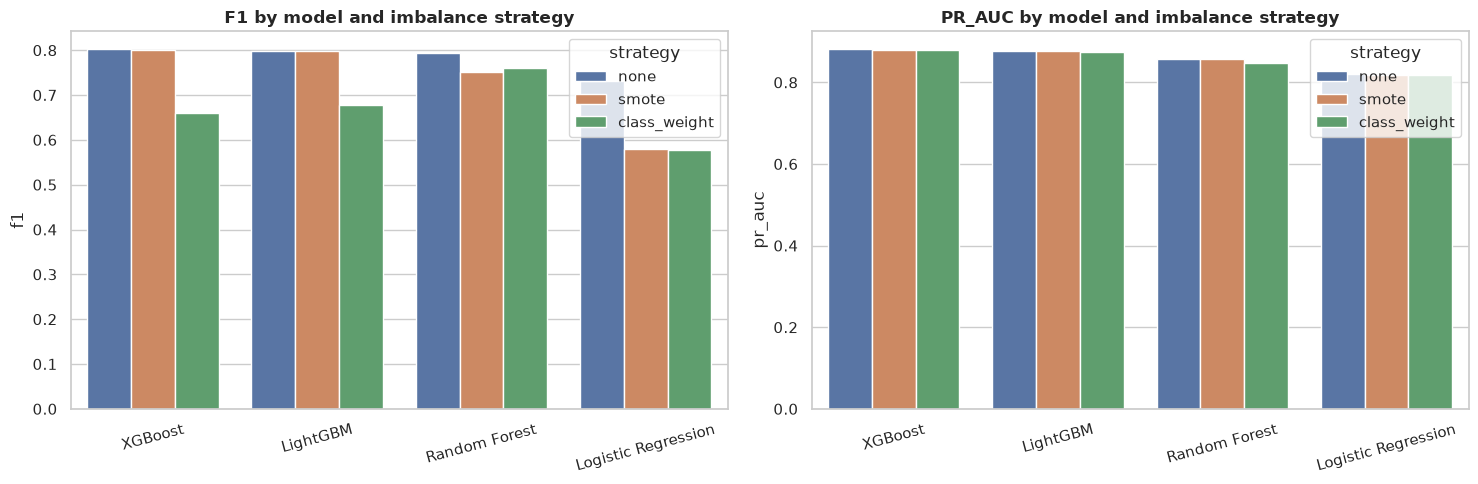

In [7]:
# Visual comparison of F1 and PR-AUC
os.makedirs('../../images', exist_ok=True)
os.makedirs('../../reports', exist_ok=True)

plot_df = results_df[results_df['model'] != 'Dummy (baseline)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['f1', 'pr_auc']):
    sns.barplot(data=plot_df, x='model', y=metric, hue='strategy', ax=ax)
    ax.set_title(f'{metric.upper()} by model and imbalance strategy', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the table for the report
results_df.to_csv('../../reports/model_comparison.csv', index=False)